# Actividad 2 — Lectura · Agraria.pe

**Fuente:** `sources/agraria-pe/sin-unificar/agro_news_2021.csv` → `agro_news_2025.csv`  
**Origen:** Scraping ético de [agraria.pe](https://agraria.pe) usando Selenium + BeautifulSoup  

## Objetivo
Leer y unificar los 5 CSVs anuales de noticias, hacer una primera inspección del contenido y documentar la cobertura temporal y calidad del texto.

## Nota sobre NLP
> El análisis de sentimiento con BETO se realizará en la **Fase 2** del proyecto. En esta fase solo se usa el conteo mensual de noticias (`n_noticias`) como variable numérica.


### Configuración inicial
Carga el `pipeline_config.json` generado en la Actividad 1 y las librerías necesarias.


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Asegurar raiz del proyecto
while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')

with open('pipeline/config/pipeline_config.json', 'r', encoding='utf-8') as f:
    CONFIG = json.load(f)

SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado correctamente.')
print('Raiz del proyecto:', os.getcwd())


Config cargado correctamente.
Raiz del proyecto: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 2.1 Lectura y unificación de los 5 CSVs anuales


In [2]:
# ============================================================
# 2.1 Leer y unificar los 5 CSVs anuales
# ============================================================
news_files = sorted(glob.glob(SOURCES['agraria_sin_unif'] + 'agro_news_*.csv'))
print(f'Archivos encontrados: {len(news_files)}')
print()

dfs_news = []
for f in news_files:
    df_tmp = pd.read_csv(f, on_bad_lines='skip', encoding='utf-8')
    anio = os.path.basename(f).replace('agro_news_','').replace('.csv','')
    df_tmp['anio_archivo'] = anio
    dfs_news.append(df_tmp)
    print(f'  {os.path.basename(f)}: {len(df_tmp):,} noticias | Columnas: {df_tmp.columns.tolist()}')

df_agraria = pd.concat(dfs_news, ignore_index=True)
print()
print(f'Dataset unificado: {df_agraria.shape}')
print()
display(df_agraria.head(3))


Archivos encontrados: 5

  agro_news_2021.csv: 44 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2022.csv: 133 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2023.csv: 118 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2024.csv: 108 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']
  agro_news_2025.csv: 125 noticias | Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo']

Dataset unificado: (528, 6)



,fecha,titular,cuerpo_completo,fuente,url,anio_archivo
0,2021-11-08,Precios mundiales de los alimentos alcanzan pico,(Agraria.pe)Los precios de los alimentos en el...,agraria.pe/alimentacion,https://agraria.pe/noticias/precios-mundiales-...,2021
1,2021-10-05,Daños en las cosechas de Brasil elevan precios...,(Agraria.pe)Las explotaciones agrícolas en Bra...,agraria.pe/alimentacion,https://agraria.pe/noticias/danos-en-las-cosec...,2021
2,2021-09-20,Crece riesgo de escasez de alimentos debido al...,(Agraria.pe)A medida que el cambio climático h...,agraria.pe/alimentacion,https://agraria.pe/noticias/crece-riesgo-de-es...,2021


## 2.2 Cobertura temporal


In [3]:
# ============================================================
# 2.2 Cobertura temporal
# ============================================================
df_agraria['fecha_dt'] = pd.to_datetime(df_agraria['fecha'], errors='coerce')
df_agraria['anio'] = df_agraria['fecha_dt'].dt.year
df_agraria['mes']  = df_agraria['fecha_dt'].dt.month

print('Rango de fechas:')
print(f'  Desde: {df_agraria["fecha_dt"].min()}')
print(f'  Hasta: {df_agraria["fecha_dt"].max()}')
print(f'  Fechas nulas: {df_agraria["fecha_dt"].isnull().sum()}')
print()
print('Noticias por año:')
print(df_agraria['anio'].value_counts().sort_index())


Rango de fechas:
  Desde: 2021-01-04 00:00:00
  Hasta: 2025-12-22 00:00:00
  Fechas nulas: 0

Noticias por año:
anio
2021     44
2022    133
2023    118
2024    108
2025    125
Name: count, dtype: int64


## 2.3 Gráfico 11 — Noticias por año


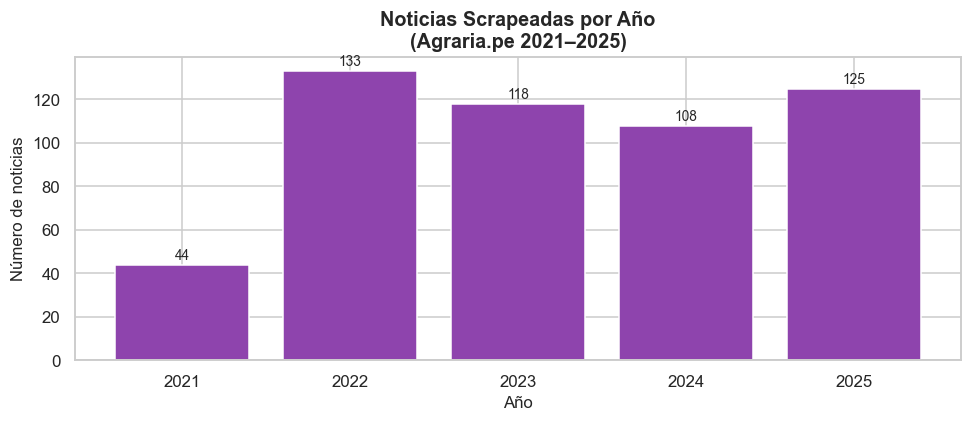

Guardado: pipeline/output/03_eda/agraria_g11_noticias_anio.png


In [4]:
# ============================================================
# GRAFICO 11: Noticias por año
# ============================================================
por_anio = df_agraria['anio'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(por_anio.index.astype(int).astype(str), por_anio.values,
              color='#8e44ad', edgecolor='white')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de noticias', fontsize=11)
ax.set_title('Noticias Scrapeadas por Año\n(Agraria.pe 2021–2025)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, por_anio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{int(val):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out_g11 = OUTPUT['eda'] + 'agraria_g11_noticias_anio.png'
plt.savefig(out_g11, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g11}')


### Interpretación — Gráfico 11

**Qué muestra:** El número de noticias disponibles por año. El año 2025 tendrá menos noticias al estar incompleto (solo hasta agosto).

**Implicación para el pipeline:** Si algún año tiene muy pocas noticias, puede indicar un problema en el scraping o que el sitio tuvo menos cobertura ese año. Esto se verificará en la Actividad 4. En la Actividad 5 se normalizará el conteo para que sea comparable entre años.

**Implicación para el modelo:** La variable `n_noticias` debe tener variabilidad suficiente entre meses para ser informativa. Un año con muy pocas noticias podría generar meses con valor 0, lo cual es válido si refleja ausencia real de cobertura.


## 2.4 Gráfico 12 — Noticias por mes (patrón estacional)


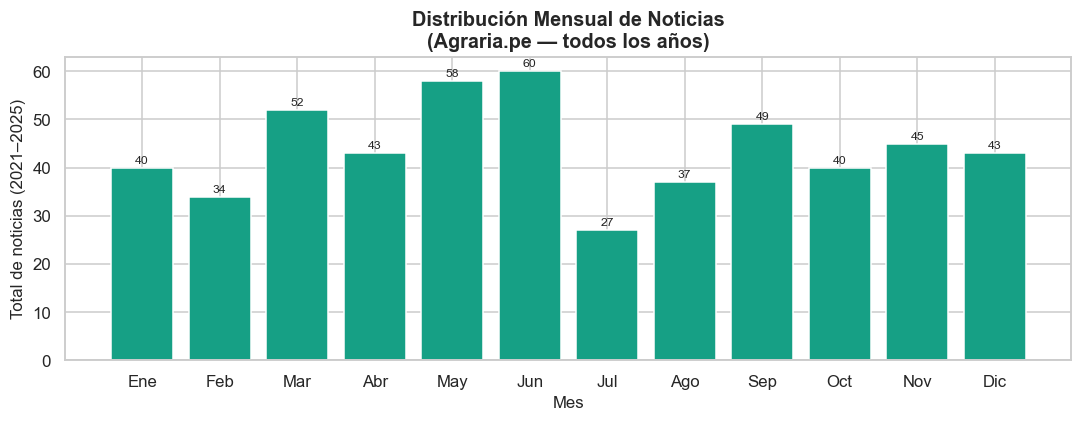

Guardado: pipeline/output/03_eda/agraria_g12_noticias_mes.png


In [5]:
# ============================================================
# GRAFICO 12: Noticias por mes (patron estacional)
# ============================================================
por_mes = df_agraria['mes'].value_counts().sort_index().dropna()
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, 13),
              [por_mes.get(m, 0) for m in range(1, 13)],
              color='#16a085', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_nombres)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Total de noticias (2021–2025)', fontsize=11)
ax.set_title('Distribución Mensual de Noticias\n(Agraria.pe — todos los años)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, [por_mes.get(m, 0) for m in range(1, 13)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(val)), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
out_g12 = OUTPUT['eda'] + 'agraria_g12_noticias_mes.png'
plt.savefig(out_g12, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g12}')


### Interpretación — Gráfico 12

**Qué muestra:** La distribución de noticias por mes sumando todos los años. Permite detectar si hay meses con cobertura periodística sistemáticamente baja.

**Implicación para el pipeline:** Meses con pocas noticias no son necesariamente un error — pueden reflejar temporadas de menor actividad agrícola. Sin embargo, si algún mes tiene 0 noticias en todos los años, se debe verificar si fue un problema de scraping.

**Implicación para el modelo:** El patrón estacional de noticias puede correlacionar con los ciclos de cosecha del limón. Si los meses de mayor producción coinciden con más noticias, la variable `n_noticias` tendrá poder predictivo adicional.


## 2.5 Gráfico 13 — Nulos por columna


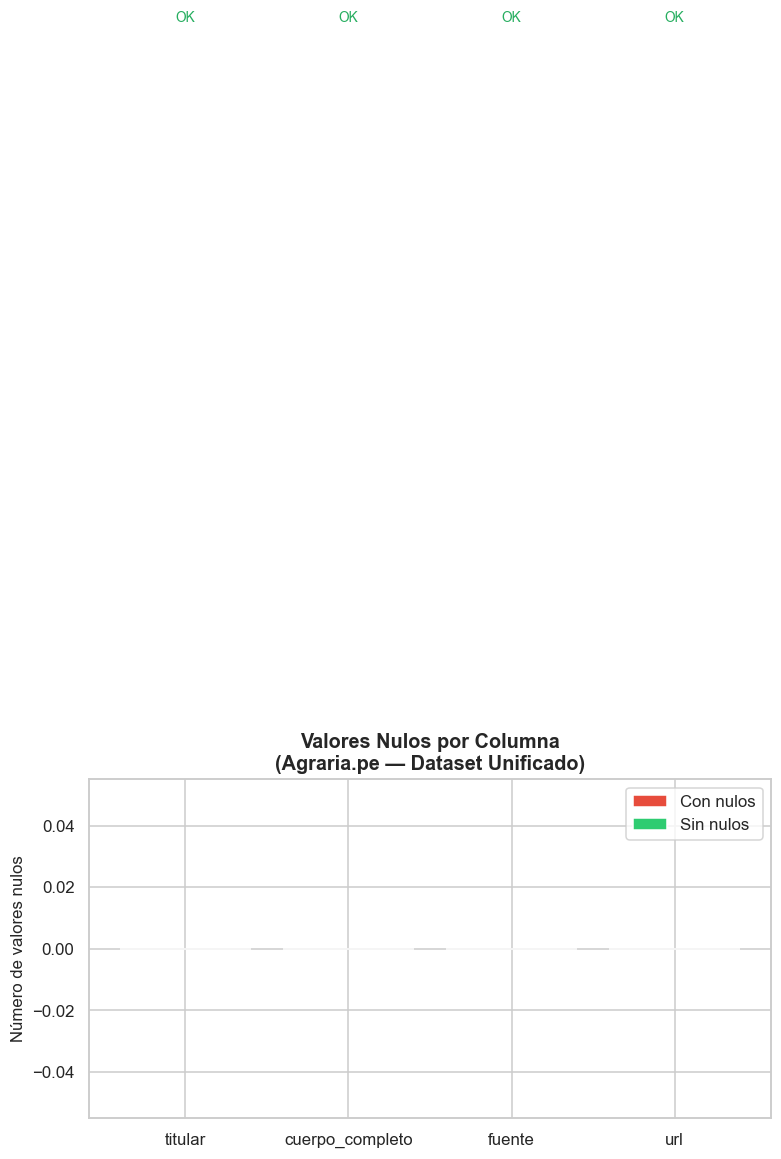

Guardado: pipeline/output/03_eda/agraria_g13_nulos_columnas.png

Resumen de nulos:
  titular                  0 nulos (0.0%)  OK
  cuerpo_completo          0 nulos (0.0%)  OK
  fuente                   0 nulos (0.0%)  OK
  url                      0 nulos (0.0%)  OK


In [6]:
# ============================================================
# GRAFICO 13: Nulos por columna
# ============================================================
cols_texto = ['titular', 'cuerpo_completo', 'fuente', 'url']
cols_texto = [c for c in cols_texto if c in df_agraria.columns]
nulos_texto = df_agraria[cols_texto].isnull().sum()
pct_nulos_texto = (nulos_texto / len(df_agraria) * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in nulos_texto.values]
bars = ax.bar(nulos_texto.index, nulos_texto.values, color=colors, edgecolor='white')
ax.set_ylabel('Número de valores nulos', fontsize=11)
ax.set_title('Valores Nulos por Columna\n(Agraria.pe — Dataset Unificado)', fontsize=13, fontweight='bold')
for bar, val, pct in zip(bars, nulos_texto.values, pct_nulos_texto.values):
    label = f'{val}\n({pct}%)' if val > 0 else 'OK'
    color = '#c0392b' if val > 0 else '#27ae60'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3 if val > 0 else 0.3,
            label, ha='center', va='bottom', fontsize=9, color=color)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Con nulos'),
                   Patch(facecolor='#2ecc71', label='Sin nulos')]
ax.legend(handles=legend_elements)
plt.tight_layout()
out_g13 = OUTPUT['eda'] + 'agraria_g13_nulos_columnas.png'
plt.savefig(out_g13, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g13}')
print()
print('Resumen de nulos:')
for col, n, p in zip(nulos_texto.index, nulos_texto.values, pct_nulos_texto.values):
    estado = 'REQUIERE LIMPIEZA' if n > 0 else 'OK'
    print(f'  {col:<20} {n:>5} nulos ({p:.1f}%)  {estado}')


### Interpretación — Gráfico 13

**Qué muestra:** El número de valores nulos en cada columna del dataset de noticias. Los nulos en `cuerpo_completo` son los más críticos para la Fase 2 (NLP con BETO).

**Implicación para el pipeline:** Las noticias sin `titular` son inutilizables y se eliminarán en la Actividad 5. Las noticias sin `cuerpo_completo` pueden conservarse para el conteo mensual (`n_noticias`) pero no para el análisis de sentimiento de la Fase 2.

**Implicación para el modelo:** Para la Fase 1, solo se necesita el conteo mensual de noticias, por lo que los nulos en `cuerpo_completo` no afectan el dataset maestro. Sin embargo, deben documentarse ahora para anticipar el trabajo de la Fase 2.


## 2.6 Exportación del raw


In [7]:
# ============================================================
# 2.6 Exportar agraria_raw.csv
# ============================================================
out_agraria = OUTPUT['lectura'] + 'agraria_raw.csv'
df_agraria.to_csv(out_agraria, index=False, encoding='utf-8-sig')
print(f'Exportado: {out_agraria}')
print(f'Shape: {df_agraria.shape}')
print(f'Columnas: {df_agraria.columns.tolist()}')
print()
print('[ACTIVIDAD 2 - AGRARIA.PE] COMPLETADA.')
print('  Siguiente paso: pipeline/fuentes/agraria-pe/actividad_03_eda_agraria.ipynb')


Exportado: pipeline/output/02_lectura/agraria_raw.csv


Shape: (528, 9)
Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'anio_archivo', 'fecha_dt', 'anio', 'mes']

[ACTIVIDAD 2 - AGRARIA.PE] COMPLETADA.
  Siguiente paso: pipeline/fuentes/agraria-pe/actividad_03_eda_agraria.ipynb
